Forcing function Hz: 102.26666666666667
Forcing function min Hz: 50.63333333333333
nf eig: [  15.42007058   53.44900664  101.777188    143.81245694  436.79026799
  729.01479799  761.69973689  761.69973689  886.15938417 1134.95367418
 1555.25209342 2098.15896182 2683.51102415 2686.44539726 4111.39674937]
find peaks:  [15.43802948 53.31690594]


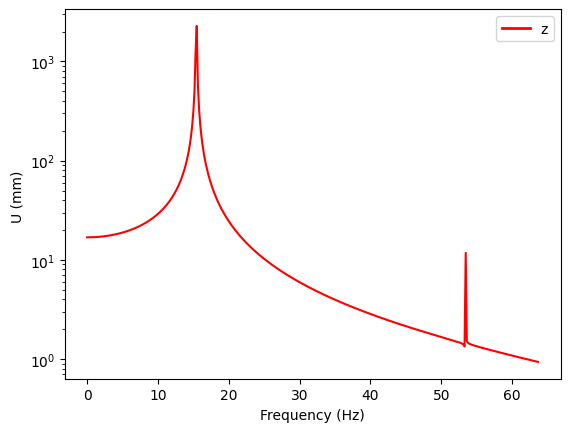

In [17]:
import math
import numpy as np
import scipy
import matplotlib.pyplot as plt
from Scripts.Mass_Analysis.drone_battery import Battery
from Scripts.drone_geometry import DroneGeometry
from Scripts.Finite_Elements.Beam_FEA_System.beam_type import BeamType
from Scripts.Mission_Profile.drone_power import BatterySystem
from Scripts.Finite_Elements.drone_fea import DroneFEA
import Scripts.unit_conversions as uc
from matplotlib.lines import Line2D

drag_coeff = 0.256

stress_FOS = 3
power_FOS = 1.25

allowable_deflection = 50.0 # mm

# https://store.tmotor.com/product/u8lite-l-kv95-u-efficiency.html
# Propeller Max RPM for 32in Propeller
Propeller_RPM = 3068
Propeller_Forcing_Function_Hz = Propeller_RPM / 30
Propeller_RPM_min = 1519
Propeller_Forcing_Function_Hz_min = Propeller_RPM_min / 30

print("Forcing function Hz:", Propeller_Forcing_Function_Hz)
print("Forcing function min Hz:", Propeller_Forcing_Function_Hz_min)

Propeller_radius = 406.4
# spacing between propellers
Propeller_spacing = 25
arm_length = (Propeller_spacing + Propeller_radius) / math.sin(22.5 * math.pi/180)

# Battery geometry
battery_1 = Battery(4.292e-3, np.array([0, 86.75, -50]), np.array([260.5, 123.5, 63.5]))
battery_2 = Battery(4.292e-3, np.array([0, -86.75, -50]), np.array([260.5, 123.5, 63.5]))

hub_radius = 200
hub_side_length = 2 * hub_radius * math.tan(math.pi/8)

# Drone Power Analysis
battery_sys = BatterySystem("Tattu 40000mAh 6S 10C 22.8V High Voltage UAV Lipo Battery Pack with AS150+AS150", 22.8, 40000, 2)

arm_length = (Propeller_spacing + Propeller_radius) / math.sin(22.5 * math.pi/180)

arm_d1,arm_t,strut_d1,strut_t,strut_dist = np.array([15.0,2.5,24.0,2.0,500.0])

arm_beam_properties = BeamType("annulus", [arm_d1 + arm_t*2, arm_d1 ], "Carbon Fiber", "arm_beam")
strut_beam_properties = BeamType("annulus", [strut_d1 + strut_t*2, strut_d1 ], "Carbon Fiber", "strut_beam")

hub_beam_properties = BeamType("i_beam", [hub_side_length*(2/3),29,2,2], "Carbon Fiber", "hub_beam")

drone_geometry = DroneGeometry("drone", arm_length, hub_radius, strut_dist, 8, arm_beam_properties, strut_beam_properties, hub_beam_properties, [battery_1, battery_2])

d1_fea = DroneFEA(drone_geometry)
d1_fea.create_drone_slice_nodes() # nominal radius | strut rad | number of blades
d1_fea.create_drone_slice_beams() # arm beam | strut beam
d1_fea.boundary_conditions_slice()
d1_fea.beam_system.init_dynamic_forces(10)
d1_fea.beam_system.add_dynamic_harmonic_force(np.array([0,0,1,0,0,0]),"outer_node")
d1_fea.solve_fea()
d1_fea.solve_natural_frequencies()

Frequencies = np.linspace(0, 400, 400)
UperF_z = np.zeros(len(Frequencies))
UperF_y = np.zeros(len(Frequencies))

UperF_mag = np.zeros(len(Frequencies))
for i, freq in enumerate(Frequencies):
    d1_fea2 = DroneFEA(drone_geometry)
    d1_fea2.create_drone_slice_nodes()
    d1_fea2.create_drone_slice_beams()
    d1_fea2.boundary_conditions_slice()
    d1_fea2.beam_system.init_dynamic_forces(freq)
    d1_fea2.beam_system.add_dynamic_harmonic_force(np.array([0,0,10,0,0,0]),"outer_node")
    d1_fea2.solve_fea()
    d1_fea2.solve_dynamic_harmonic(0,0)
    UperF_z[i] = abs(d1_fea2.beam_system.z_displacements_amplitude[d1_fea2.beam_system.select_node("outer_node")])
    UperF_y[i] = abs(d1_fea2.beam_system.z_displacements_amplitude[d1_fea2.beam_system.select_node("outer_node")])


peaks, _ = scipy.signal.find_peaks(UperF_z)
print("nf eig:", d1_fea.beam_system.natural_frequencies * uc.rad_per_s_to_Hz)
print("find peaks: ",peaks * uc.rad_per_s_to_Hz)

plt.plot(Frequencies  * uc.rad_per_s_to_Hz, UperF_z, color='r')
# plt.plot(Frequencies * uc.rad_per_s_to_Hz, UperF_y, color='g')
plt.yscale('log')
plt.xlabel("Frequency (Hz)")
plt.ylabel("U (mm) ")


legend_elements = [
    Line2D([0], [0], color='r', lw=2, label='z'),
]

plt.legend(handles=legend_elements, loc='upper right')

In [9]:

import numpy as np
import matplotlib.pyplot as plt
from Scripts.Finite_Elements.Beam_FEA_System.beam_system import BeamSystem
from Scripts.Finite_Elements.Beam_FEA_System.beam_type import BeamType
from Scripts.Mission_Profile.mission_profile import MissionProfile
from matplotlib.lines import Line2D


arm_beam_properties = BeamType("annulus", [18,15], "Carbon Fiber", "arm_beam")

beam_sys = BeamSystem("Cantilever")
beam_sys.add_node(np.array([0,0,0]),"origin")
beam_sys.add_node(np.array([1000,0,0]),"endpoint")
beam_sys.add_beam(arm_beam_properties,"origin","endpoint",np.array([0,1,0]),"cantilever")
beam_sys.add_boundary_condition(0,"en castre","origin")
beam_sys.add_boundary_condition(0,"x","endpoint")
beam_sys.add_boundary_condition(0,"z","endpoint")
beam_sys.add_boundary_condition(0,"theta x","endpoint")
beam_sys.add_boundary_condition(0,"theta y","endpoint")
beam_sys.add_boundary_condition(0,"theta z","endpoint")
beam_sys.add_force(np.array([0,-1,0]),"endpoint")
beam_sys.add_dynamic_harmonic_force(np.array([0,1,0,0,0,0]),0,0,"endpoint")
beam_sys.solve_FEA()
beam_sys.solve_static()
beam_sys.solve_dynamic_harmonic(6,0.002)
beam_sys.solve_natural_frequencies()
print(beam_sys.natural_frequencies)


Frequencies = np.linspace(0, 120, 40)
UperF_z = np.zeros(len(Frequencies))
UperF_y = np.zeros(len(Frequencies))

for i, freq in enumerate(Frequencies):
    end_node = beam_sys.select_node("endpoint")
    beam_sys.nodes[end_node].dynamic_forces_frequency[0] = freq # update freq
    beam_sys.solve_dynamic_harmonic(1.6,0.0002)
    print(freq,"|",beam_sys.y_displacements_amplitude[0][end_node])
    UperF_z[i] = abs(beam_sys.z_displacements_amplitude[0][end_node])
    UperF_y[i] = abs(beam_sys.y_displacements_amplitude[0][end_node])

plt.plot(Frequencies, UperF_z, color='r')
plt.plot(Frequencies, UperF_y, color='g')
plt.yscale('log')
plt.xlabel("Frequency (Hz)")
plt.ylabel("U (mm) ")
print("Static: ",beam_sys.y_displacements)

legend_elements = [
    Line2D([0], [0], color='r', lw=2, label='z'),
    Line2D([0], [0], color='g', lw=2, label='y'),
]

plt.legend(handles=legend_elements, loc='upper right')


ImportError: cannot import name 'MissionProfile' from 'Scripts.Mission_Profile.mission_profile' (C:\Desktop\UAV_Mission\Scripts\Mission_Profile\mission_profile.py)